# Chapter 13: Willmore Surfaces

Source orientation: printed pages 181-191; PDF pages 183-193. This notebook is original standalone course material for Chapter 13 of *Differential Geometry: From Elastic Curves to Willmore Surfaces*. It uses the source span for notation, order, and theorem targets, but the prose, examples, code, and artifacts here are newly authored for this course.

## Chapter Goal

Chapter 13 asks what replaces the bending energy of a curve when the moving object is a surface. The answer is not a single picture of a curved sheet. It is a family of integrals built from the principal curvatures:

\[
W(f)=\int_M H^2\,dA, \qquad
E(f)=\int_M \left(H^2-\frac{K}{2}\right)dA, \qquad
\widehat W(f)=\int_M (H^2-K)\,dA.
\]

The notebook turns those formulas into inspectable objects. You will compare the three energies, see why Gauss-Bonnet makes their variational content nearly the same, test the Euler-Lagrange expression

\[
\Delta H+2H(H^2-K)=0,
\]

and check the pointwise density identity that makes inversion preserve the conformal Willmore functional away from its center.

The chapter is short, but it sits at the intersection of almost every surface topic developed earlier in the book. Mean curvature comes from the shape operator, Gaussian curvature brings in Gauss-Bonnet, the variation formula uses the surface divergence theorem, and inversion uses a conformal change of metric. The notebook keeps those strands separate before putting them together. That separation matters: a sphere minimizes the genus-zero bound because it is umbilic, a Clifford torus is special because its Willmore residual vanishes, and an inverted surface remains Willmore for a conformal reason rather than because the inverted picture looks simple.

## Computational Translation Guide

| Chapter language | Computational representation | What we check |
|---|---|---|
| principal curvatures `k1`, `k2` | sampled arrays on parameter grids or exact symbolic expressions | `H=(k1+k2)/2`, `K=k1*k2`, and quadrature agree with exact formulas |
| Willmore, bending, conformal energies | numerical sums of `H^2 dA`, `(H^2-K/2)dA`, and `(H^2-K)dA` | sphere and Clifford torus hit the expected benchmark energies |
| Gauss-Bonnet offset | `int K dA = 4*pi*(1-g)` for closed orientable examples | `E-W=-1/2 int K dA` and `W_hat-W=-int K dA` |
| Willmore equation | residual field `Delta H + 2H(H^2-K)` | sphere and Clifford torus residuals vanish; a cylinder reduces to the elastic-curve ODE |
| inversion in the unit sphere | point map `p -> p/<p,p>` plus the curvature-gap transformation | `(H^2-K)dA` matches before and after inversion, while the surface shape changes visibly |

Matplotlib is used for durable diagnostic figures and proof scaffolds. Plotly is used where Chapter 13 genuinely needs a rotatable 3D surface view. SymPy carries exact algebra for the torus residual and energy offsets. NumPy supplies the parameter grids, quadrature, and the small free-elastica ODE sampler.

The computations intentionally use analytic parameterizations for the sphere, round tori, and cylinders. A general mesh estimator for mean curvature would be useful in a numerical geometry course, but here it would hide the specific identities Chapter 13 is trying to teach. The goal is to see each factor in the integrand: the principal-curvature gap, the area scaling, the topological Gaussian term, and the Laplace-Beltrami contribution to the Euler-Lagrange residual. Once those are visible in controlled examples, the final checks make clear which statements are exact, which are quadrature approximations, and which are qualitative visual guides.

In [1]:
from __future__ import annotations

from pathlib import Path
import json
import math
import sys

from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import sympy as sp

BOOK_ROOT = Path.cwd()
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find the DGE-CWS book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import ARTIFACT_ROOT, display_artifact, save_json, save_matplotlib, save_plotly_html
from utils.plotting import PALETTE, add_note, image_stats, style_axis
from utils.willmore import invert_points, sphere_willmore_energy

TOPIC = "chapter-13"
CHAPTER_DIR = BOOK_ROOT / "part-02-surfaces" / "chapter-13-willmore-surfaces"
CHAPTER_ARTIFACT_ROOT = ARTIFACT_ROOT / TOPIC
for subfolder in ["figures", "interactive", "checks"]:
    (CHAPTER_ARTIFACT_ROOT / subfolder).mkdir(parents=True, exist_ok=True)

TAU = 2.0 * math.pi
ARTIFACTS: list[Path] = []
CHECKS: dict[str, object] = {}


def record_artifact(path: Path) -> Path:
    ARTIFACTS.append(path)
    return path


def rel(path: Path) -> str:
    return path.relative_to(BOOK_ROOT).as_posix()


def markdown_table(rows: list[list[object]], headers: list[str]) -> Markdown:
    lines = ["| " + " | ".join(headers) + " |", "|" + "|".join(["---"] * len(headers)) + "|"]
    for row in rows:
        lines.append("| " + " | ".join(str(item) for item in row) + " |")
    return Markdown("\n".join(lines))


print(f"Book root: {BOOK_ROOT}")
print(f"Artifact root: {CHAPTER_ARTIFACT_ROOT.relative_to(BOOK_ROOT)}")

Book root: D:\Geometry\Differential-Geometry-From-Elastic-Curves-to-Willmore-Surfaces
Artifact root: artifacts\chapter-13


## Chapter-Specific Storyboard

This storyboard is the implementation plan for the chapter. Each artifact has a job: it either exposes a curvature density, tests an offset formula, makes a variational residual visible, or checks the inversion identity behind conformal invariance.

In [2]:
storyboard = {
    "chapter_goal": "Interpret Willmore surfaces through energy variants, Euler-Lagrange residuals, elastic-cylinder reduction, and inversion invariance.",
    "source_span_read": {
        "printed_pages": "181-191",
        "pdf_pages": "183-193",
        "source_map_focus": "Willmore functional, Willmore equation, energy offsets, cylinder examples, and inversion invariance.",
    },
    "concept_inventory": [
        "W(f)=integral H^2 dA as the surface analog of squared curvature energy",
        "E(f)=integral(H^2-K/2)dA and W_hat(f)=integral(H^2-K)dA differ from W by Gaussian-curvature terms",
        "Gauss-Bonnet turns those differences into genus offsets for closed surfaces",
        "Willmore surfaces satisfy Delta H + 2H(H^2-K)=0 away from boundary terms",
        "cylinders over plane curves reduce the Willmore equation to kappa'' + kappa^3/2 = 0",
        "inversion rescales metric and area while preserving the conformal density (H^2-K)dA",
    ],
    "library_routing_table": [
        {"concept": "energy variants and offsets", "representation": "bar charts plus exact identities", "library": "Matplotlib + SymPy", "why": "static comparisons and exact genus-offset algebra are most readable here"},
        {"concept": "surface examples", "representation": "parameterized surface grids colored by curvature density", "library": "NumPy + Matplotlib", "why": "small analytic grids keep curvature formulas visible"},
        {"concept": "inversion behavior", "representation": "rotatable original/inverted 3D surfaces", "library": "Plotly", "why": "the learner needs to rotate both surfaces and inspect the shared density scale"},
        {"concept": "proof dependencies", "representation": "directed theorem graph", "library": "NetworkX + Matplotlib", "why": "the source proof chain is structural rather than decorative"},
    ],
    "visual_sequence": [
        {"artifact": "figures/willmore-energy-zoo.png", "inspection_target": "which surfaces make H^2 and H^2-K visually different", "validation": "sphere W=4*pi and Clifford torus W=2*pi^2"},
        {"artifact": "figures/gauss-bonnet-energy-offsets.png", "inspection_target": "how K changes the three energies without changing compactly supported first variations", "validation": "offsets match total Gaussian curvature"},
        {"artifact": "figures/willmore-equation-and-elastic-cylinder.png", "inspection_target": "where the Euler-Lagrange residual vanishes", "validation": "Clifford torus residual and elastic-cylinder ODE residual are small"},
        {"artifact": "interactive/inversion-conformal-density-lab.html", "inspection_target": "same conformal density on very different inverted shapes", "validation": "pointwise density error below tolerance away from the inversion center"},
        {"artifact": "figures/willmore-proof-dependency.png", "inspection_target": "which earlier facts feed the Willmore equation and inversion theorem", "validation": "graph has the intended theorem sinks"},
    ],
    "computational_checks": [
        "exact sphere scale invariance",
        "exact torus energy minimum at R/r=sqrt(2)",
        "Gauss-Bonnet offsets for genus 0 and 1 examples",
        "symbolic torus residual q*(q^2-2)/(4*(q+cos v)^3)",
        "numerical free-elastica cylinder residual",
        "inversion conformal-density preservation",
        "artifact existence and nonblank image statistics",
    ],
    "risks": [
        "mesh-free parameter grids avoid new dependencies but do not approximate arbitrary Willmore surfaces",
        "inversion checks avoid the center singularity by translating the sampled torus away from the origin",
        "source figures are not copied; all visuals are generated from formulas in this notebook",
    ],
}

routing_rows = []
for item in storyboard["library_routing_table"]:
    routing_rows.append([item["concept"], item["representation"], item["library"], item["why"]])
display(markdown_table(routing_rows, ["Concept", "Representation", "Library", "Reason"]))

storyboard_path = record_artifact(save_json(storyboard, TOPIC, "checks", "visual-storyboard.json"))
display_artifact(storyboard_path)

| Concept | Representation | Library | Reason |
|---|---|---|---|
| energy variants and offsets | bar charts plus exact identities | Matplotlib + SymPy | static comparisons and exact genus-offset algebra are most readable here |
| surface examples | parameterized surface grids colored by curvature density | NumPy + Matplotlib | small analytic grids keep curvature formulas visible |
| inversion behavior | rotatable original/inverted 3D surfaces | Plotly | the learner needs to rotate both surfaces and inspect the shared density scale |
| proof dependencies | directed theorem graph | NetworkX + Matplotlib | the source proof chain is structural rather than decorative |

## 1. The Three Curvature-Squared Energies

The chapter starts by asking what the surface version of curve bending energy should be. A surface has two principal curvatures, so there are several honest answers. `W` measures mean-curvature bending. `E` measures deviation from being flat. `W_hat` measures deviation from being umbilic, hence from being locally spherical.

The next cell defines the analytic grids used throughout the notebook. Keeping the formulas in the notebook is intentional: the learner should see exactly where `H`, `K`, and `dA` enter each diagnostic.

In [3]:
def periodic_grid(nu: int = 96, nv: int = 72) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, float, float]:
    u = np.linspace(0.0, TAU, nu, endpoint=False)
    v = np.linspace(0.0, TAU, nv, endpoint=False)
    U, V = np.meshgrid(u, v, indexing="ij")
    return u, v, U, V, float(u[1] - u[0]), float(v[1] - v[0])


def integrate_periodic(values: np.ndarray, du: float, dv: float) -> float:
    return float(np.sum(values) * du * dv)


def torus_data(R: float, r: float, *, nu: int = 128, nv: int = 96, shift: tuple[float, float, float] = (0.0, 0.0, 0.0)) -> dict[str, np.ndarray | float]:
    _, _, U, V, du, dv = periodic_grid(nu, nv)
    radial = R + r * np.cos(V)
    X = radial * np.cos(U) + shift[0]
    Y = radial * np.sin(U) + shift[1]
    Z = r * np.sin(V) + shift[2]
    N = np.stack([np.cos(U) * np.cos(V), np.sin(U) * np.cos(V), np.sin(V)], axis=-1)
    k1 = np.cos(V) / radial
    k2 = np.full_like(k1, 1.0 / r)
    H = 0.5 * (k1 + k2)
    K = k1 * k2
    dA = r * radial
    W_density = H * H * dA
    E_density = (H * H - 0.5 * K) * dA
    conformal_density = (H * H - K) * dA
    return {
        "U": U, "V": V, "X": X, "Y": Y, "Z": Z, "N": N,
        "k1": k1, "k2": k2, "H": H, "K": K, "dA": dA,
        "W_density": W_density, "E_density": E_density, "conformal_density": conformal_density,
        "du": du, "dv": dv,
        "W": integrate_periodic(W_density, du, dv),
        "E": integrate_periodic(E_density, du, dv),
        "W_hat": integrate_periodic(conformal_density, du, dv),
        "total_K": integrate_periodic(K * dA, du, dv),
    }


def sphere_data(radius: float = 1.0, *, ntheta: int = 160, nphi: int = 320) -> dict[str, np.ndarray | float]:
    theta = (np.arange(ntheta) + 0.5) * math.pi / ntheta
    phi = (np.arange(nphi) + 0.5) * TAU / nphi
    TH, PH = np.meshgrid(theta, phi, indexing="ij")
    X = radius * np.sin(TH) * np.cos(PH)
    Y = radius * np.sin(TH) * np.sin(PH)
    Z = radius * np.cos(TH)
    dtheta = math.pi / ntheta
    dphi = TAU / nphi
    dA = radius * radius * np.sin(TH)
    H = np.full_like(TH, 1.0 / radius)
    K = np.full_like(TH, 1.0 / (radius * radius))
    W_density = H * H * dA
    E_density = (H * H - 0.5 * K) * dA
    conformal_density = (H * H - K) * dA
    return {
        "TH": TH, "PH": PH, "X": X, "Y": Y, "Z": Z,
        "H": H, "K": K, "dA": dA,
        "W_density": W_density, "E_density": E_density, "conformal_density": conformal_density,
        "du": dtheta, "dv": dphi,
        "W": float(np.sum(W_density) * dtheta * dphi),
        "E": float(np.sum(E_density) * dtheta * dphi),
        "W_hat": float(np.sum(conformal_density) * dtheta * dphi),
        "total_K": float(np.sum(K * dA) * dtheta * dphi),
    }


def torus_willmore_exact(R: float, r: float) -> float:
    if R <= r:
        raise ValueError("A ring torus needs R > r")
    return math.pi**2 * R * R / (r * math.sqrt(R * R - r * r))


def energy_variants(W: float, total_K: float) -> dict[str, float]:
    return {"W": W, "E": W - 0.5 * total_K, "W_hat": W - total_K}


def surface_colors(values: np.ndarray, cmap_name: str = "viridis") -> np.ndarray:
    vals = np.asarray(values, dtype=float)
    scaled = (vals - float(np.nanmin(vals))) / (float(np.nanmax(vals) - np.nanmin(vals)) + 1e-12)
    return plt.get_cmap(cmap_name)(scaled)


def set_surface_axes(ax, title: str) -> None:
    ax.set_title(title, fontsize=10, color=PALETTE["ink"])
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.set_box_aspect((1, 1, 0.72))
    ax.view_init(elev=24, azim=-48)
    ax.set_facecolor("white")

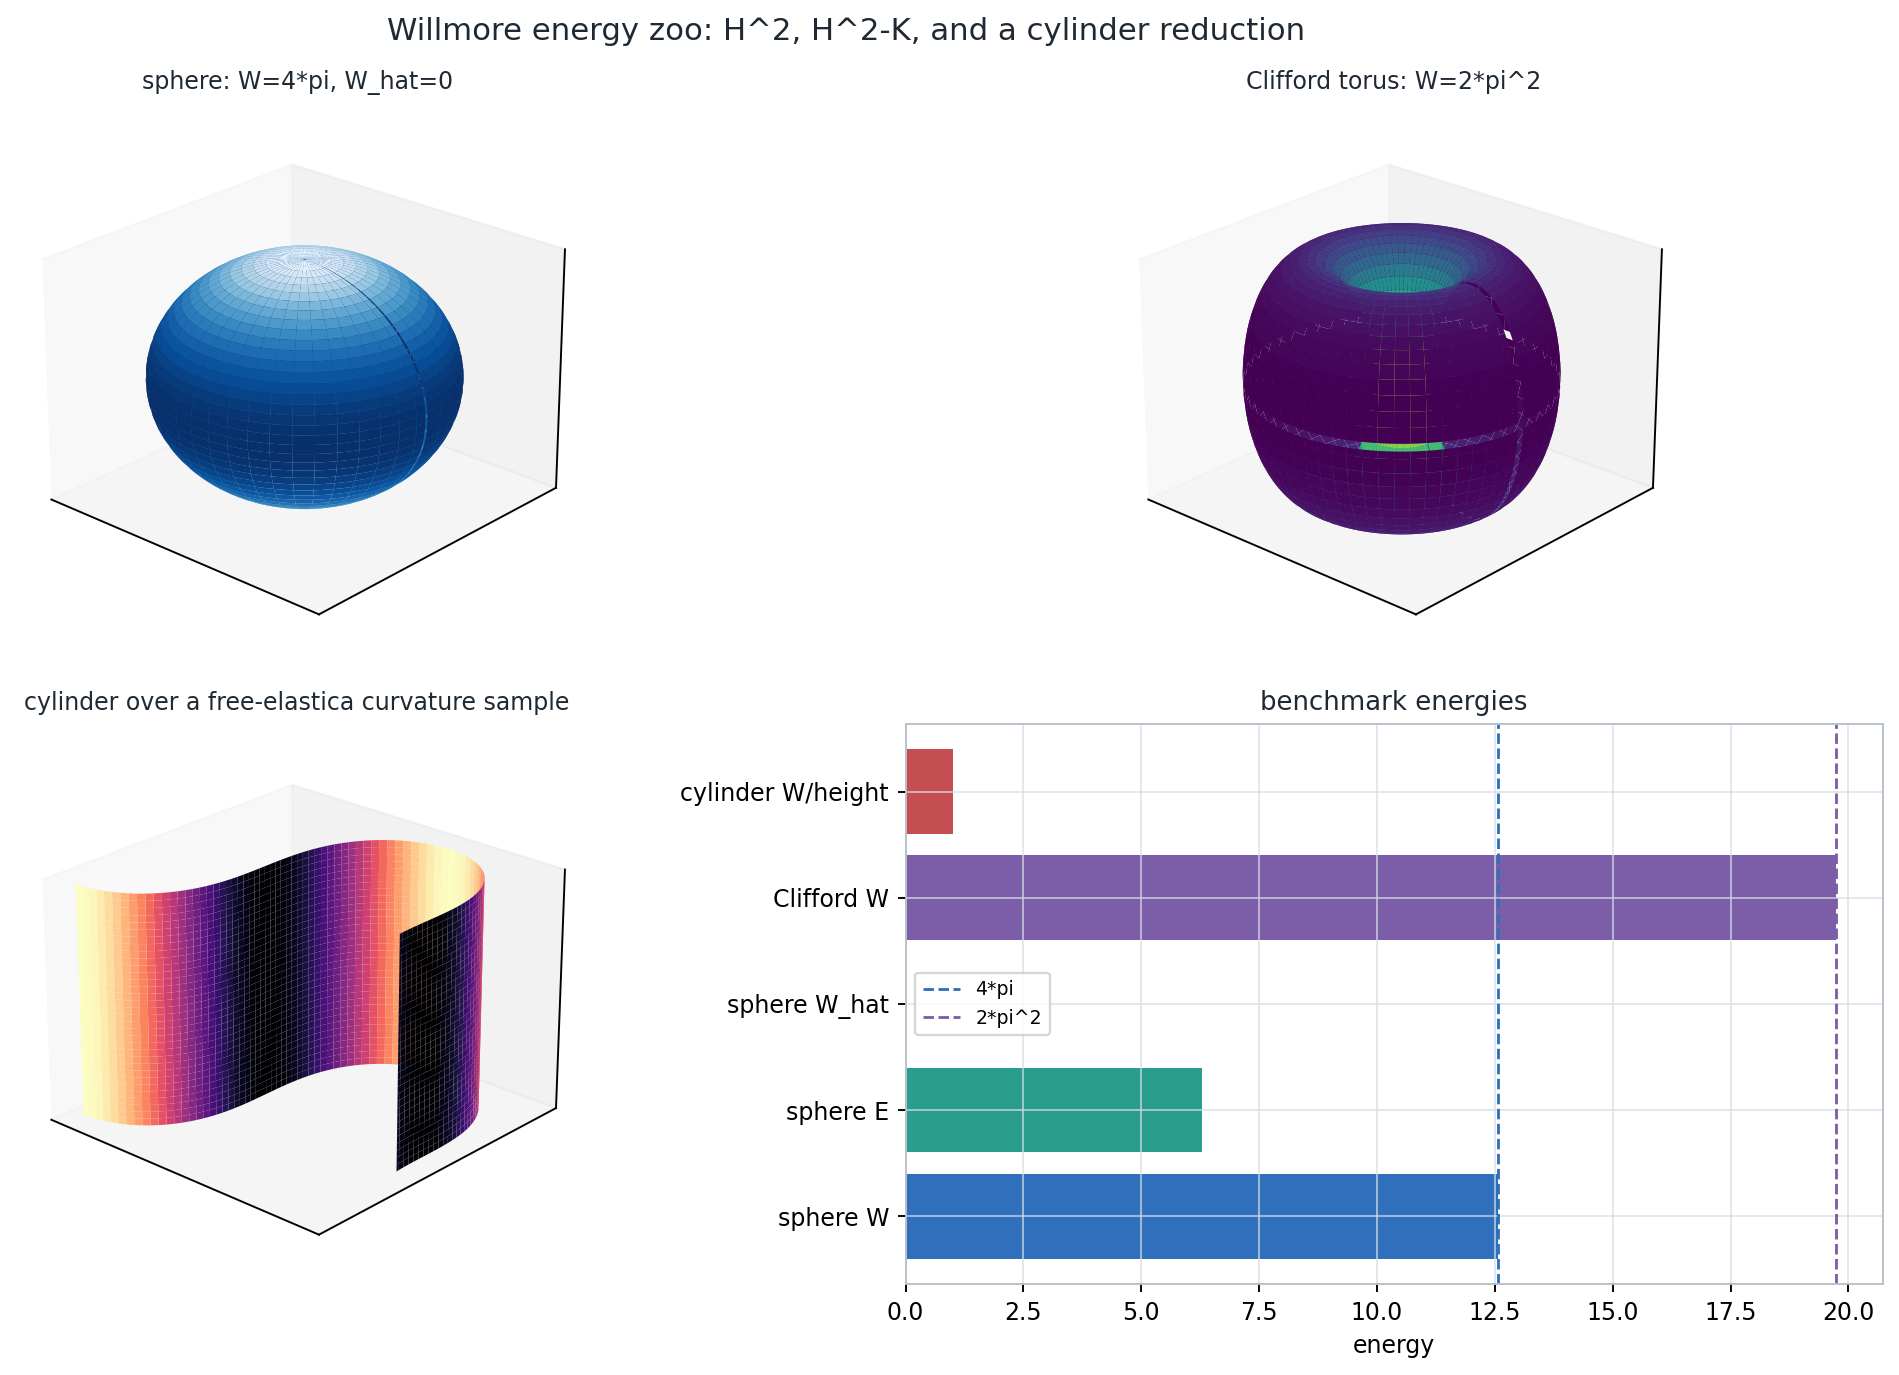

In [4]:
sphere = sphere_data(1.0)
clifford = torus_data(math.sqrt(2.0), 1.0)


def free_elastica_cylinder(k0: float = 1.12, length: float = 7.5, samples: int = 520, width: float = 1.2, width_samples: int = 34) -> dict[str, np.ndarray | float]:
    """Sample the source cylinder example through kappa'' + kappa^3/2 = 0."""
    s = np.linspace(0.0, length, samples)
    h = float(s[1] - s[0])
    state = np.zeros((samples, 5), dtype=float)  # kappa, kappa_prime, tangent angle, x, y
    state[0] = [k0, 0.0, 0.0, 0.0, 0.0]

    def rhs(y: np.ndarray) -> np.ndarray:
        kappa, kappa_prime, theta, _, _ = y
        return np.array([kappa_prime, -0.5 * kappa**3, kappa, math.cos(theta), math.sin(theta)], dtype=float)

    for i in range(samples - 1):
        y = state[i]
        k_1 = rhs(y)
        k_2 = rhs(y + 0.5 * h * k_1)
        k_3 = rhs(y + 0.5 * h * k_2)
        k_4 = rhs(y + h * k_3)
        state[i + 1] = y + (h / 6.0) * (k_1 + 2 * k_2 + 2 * k_3 + k_4)

    kappa = state[:, 0]
    kappa_prime = state[:, 1]
    x = state[:, 3]
    y = state[:, 4]
    z = np.linspace(-0.5 * width, 0.5 * width, width_samples)
    X = np.repeat(x[:, None], width_samples, axis=1)
    Y = np.repeat(y[:, None], width_samples, axis=1)
    Z = np.repeat(z[None, :], samples, axis=0)
    H = 0.5 * np.repeat(kappa[:, None], width_samples, axis=1)
    residual = np.gradient(kappa_prime, s, edge_order=2) + 0.5 * kappa**3
    W_per_unit_width = float(0.25 * np.trapezoid(kappa * kappa, s))
    return {"s": s, "kappa": kappa, "kappa_prime": kappa_prime, "residual": residual, "x": x, "y": y, "X": X, "Y": Y, "Z": Z, "H": H, "W_per_unit_width": W_per_unit_width}


elastic_cyl = free_elastica_cylinder()

fig = plt.figure(figsize=(12.5, 8.2))
ax = fig.add_subplot(2, 2, 1, projection="3d")
ax.plot_surface(sphere["X"], sphere["Y"], sphere["Z"], facecolors=surface_colors(sphere["W_density"], "Blues"), linewidth=0, antialiased=True, shade=False)
set_surface_axes(ax, "sphere: W=4*pi, W_hat=0")

ax = fig.add_subplot(2, 2, 2, projection="3d")
ax.plot_surface(clifford["X"], clifford["Y"], clifford["Z"], facecolors=surface_colors(clifford["conformal_density"], "viridis"), rstride=2, cstride=2, linewidth=0, antialiased=True, shade=False)
set_surface_axes(ax, "Clifford torus: W=2*pi^2")

ax = fig.add_subplot(2, 2, 3, projection="3d")
ax.plot_surface(elastic_cyl["X"], elastic_cyl["Y"], elastic_cyl["Z"], facecolors=surface_colors(elastic_cyl["H"] ** 2, "magma"), rstride=6, cstride=1, linewidth=0, antialiased=True, shade=False)
set_surface_axes(ax, "cylinder over a free-elastica curvature sample")

ax = fig.add_subplot(2, 2, 4)
energy_labels = ["sphere W", "sphere E", "sphere W_hat", "Clifford W", "cylinder W/height"]
energy_values = [4 * math.pi, 2 * math.pi, 0.0, 2 * math.pi**2, elastic_cyl["W_per_unit_width"]]
colors = [PALETTE["blue"], PALETTE["teal"], PALETTE["gray"], PALETTE["violet"], PALETTE["red"]]
ax.barh(energy_labels, energy_values, color=colors)
ax.axvline(4 * math.pi, color=PALETTE["blue"], linestyle="--", linewidth=1.2, label="4*pi")
ax.axvline(2 * math.pi**2, color=PALETTE["violet"], linestyle="--", linewidth=1.2, label="2*pi^2")
ax.set_xlabel("energy")
style_axis(ax, "benchmark energies")
ax.legend(fontsize=8)
fig.suptitle("Willmore energy zoo: H^2, H^2-K, and a cylinder reduction", fontsize=13, color=PALETTE["ink"])
fig.tight_layout()

energy_zoo_path = record_artifact(save_matplotlib(fig, TOPIC, "figures", "willmore-energy-zoo.png", dpi=170))
plt.close(fig)
display_artifact(energy_zoo_path, width=960)

CHECKS["sphere_willmore_numeric_error"] = abs(float(sphere["W"]) - 4 * math.pi)
CHECKS["sphere_willmore_exact_scale_errors"] = {str(radius): abs(sphere_willmore_energy(radius) - 4 * math.pi) for radius in [0.5, 1.0, 2.0, 4.0]}
CHECKS["clifford_torus_energy_error"] = abs(float(clifford["W"]) - 2 * math.pi**2)
CHECKS["clifford_torus_total_K_abs"] = abs(float(clifford["total_K"]))
CHECKS["elastic_cylinder_W_per_unit_width"] = float(elastic_cyl["W_per_unit_width"])

## 2. Gauss-Bonnet Explains the Energy Offsets

The three functionals are not equal, but their differences are multiples of `int K dA`. For compactly supported variations inside a surface patch, the Gaussian-curvature contribution has no local first-variation effect. For a closed orientable surface, Gauss-Bonnet makes the difference topological:

\[
\int_M K\,dA=4\pi(1-g), \qquad
E-W=2\pi(g-1), \qquad
\widehat W-W=4\pi(g-1).
\]

That is why the chapter can move between `W`, `E`, and `W_hat` while still talking about the same critical surfaces in the variational sense.

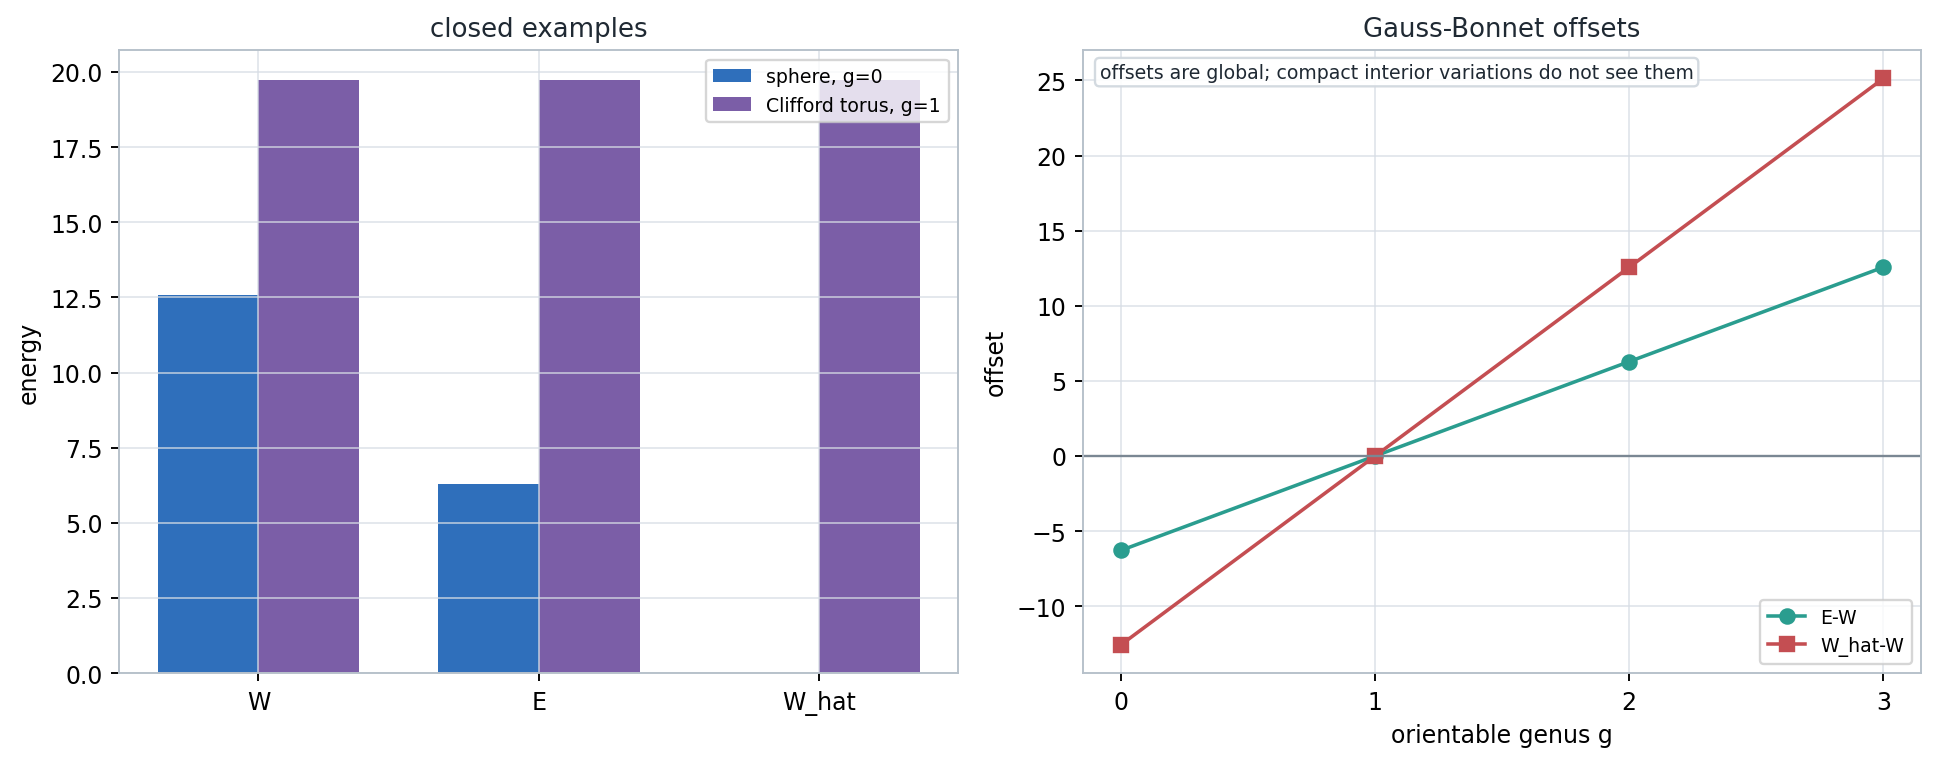

In [5]:
sphere_offsets = energy_variants(4 * math.pi, 4 * math.pi)
torus_offsets = energy_variants(2 * math.pi**2, 0.0)

genera = np.array([0, 1, 2, 3], dtype=float)
E_minus_W = 2 * math.pi * (genera - 1)
What_minus_W = 4 * math.pi * (genera - 1)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
width = 0.36
x = np.arange(3)
labels = ["W", "E", "W_hat"]
axes[0].bar(x - width / 2, [sphere_offsets[k] for k in labels], width, label="sphere, g=0", color=PALETTE["blue"])
axes[0].bar(x + width / 2, [torus_offsets[k] for k in labels], width, label="Clifford torus, g=1", color=PALETTE["violet"])
axes[0].set_xticks(x, labels)
axes[0].set_ylabel("energy")
style_axis(axes[0], "closed examples")
axes[0].legend(fontsize=8)

axes[1].plot(genera, E_minus_W, marker="o", color=PALETTE["teal"], label="E-W")
axes[1].plot(genera, What_minus_W, marker="s", color=PALETTE["red"], label="W_hat-W")
axes[1].axhline(0, color=PALETTE["gray"], linewidth=1)
axes[1].set_xticks(genera)
axes[1].set_xlabel("orientable genus g")
axes[1].set_ylabel("offset")
style_axis(axes[1], "Gauss-Bonnet offsets")
axes[1].legend(fontsize=8)
add_note(axes[1], "offsets are global; compact interior variations do not see them")
fig.tight_layout()

offset_path = record_artifact(save_matplotlib(fig, TOPIC, "figures", "gauss-bonnet-energy-offsets.png", dpi=170))
plt.close(fig)
display_artifact(offset_path, width=920)

offset_checks = {
    "sphere": {
        "total_K": 4 * math.pi,
        "W": sphere_offsets["W"],
        "E": sphere_offsets["E"],
        "W_hat": sphere_offsets["W_hat"],
        "E_offset_error": abs((sphere_offsets["E"] - sphere_offsets["W"]) - 2 * math.pi * (0 - 1)),
        "W_hat_offset_error": abs((sphere_offsets["W_hat"] - sphere_offsets["W"]) - 4 * math.pi * (0 - 1)),
    },
    "clifford_torus": {
        "total_K": 0.0,
        "W": torus_offsets["W"],
        "E": torus_offsets["E"],
        "W_hat": torus_offsets["W_hat"],
        "E_offset_error": abs(torus_offsets["E"] - torus_offsets["W"]),
        "W_hat_offset_error": abs(torus_offsets["W_hat"] - torus_offsets["W"]),
    },
    "offset_formula": "E-W=2*pi*(g-1), W_hat-W=4*pi*(g-1) for closed orientable genus g",
}
offset_checks_path = record_artifact(save_json(offset_checks, TOPIC, "checks", "gauss-bonnet-energy-offsets.json"))
display_artifact(offset_checks_path)

CHECKS["sphere_offset_max_error"] = max(offset_checks["sphere"]["E_offset_error"], offset_checks["sphere"]["W_hat_offset_error"])
CHECKS["torus_offset_max_error"] = max(offset_checks["clifford_torus"]["E_offset_error"], offset_checks["clifford_torus"]["W_hat_offset_error"])

## 3. The Willmore Equation and the Elastic-Cylinder Reduction

The first variation formula in the source has an interior term and a boundary term. If the variation is compactly supported away from the boundary, only the interior coefficient of the normal speed matters. Criticality forces

\[
\Delta H+2H(H^2-K)=0.
\]

This is a fourth-order condition on the original immersion because `H` already contains second derivatives of the surface. Two useful checks make the formula less opaque: a Clifford torus makes the residual vanish exactly, and a cylinder over a plane curve reduces the surface equation to the free-elastica curvature equation.

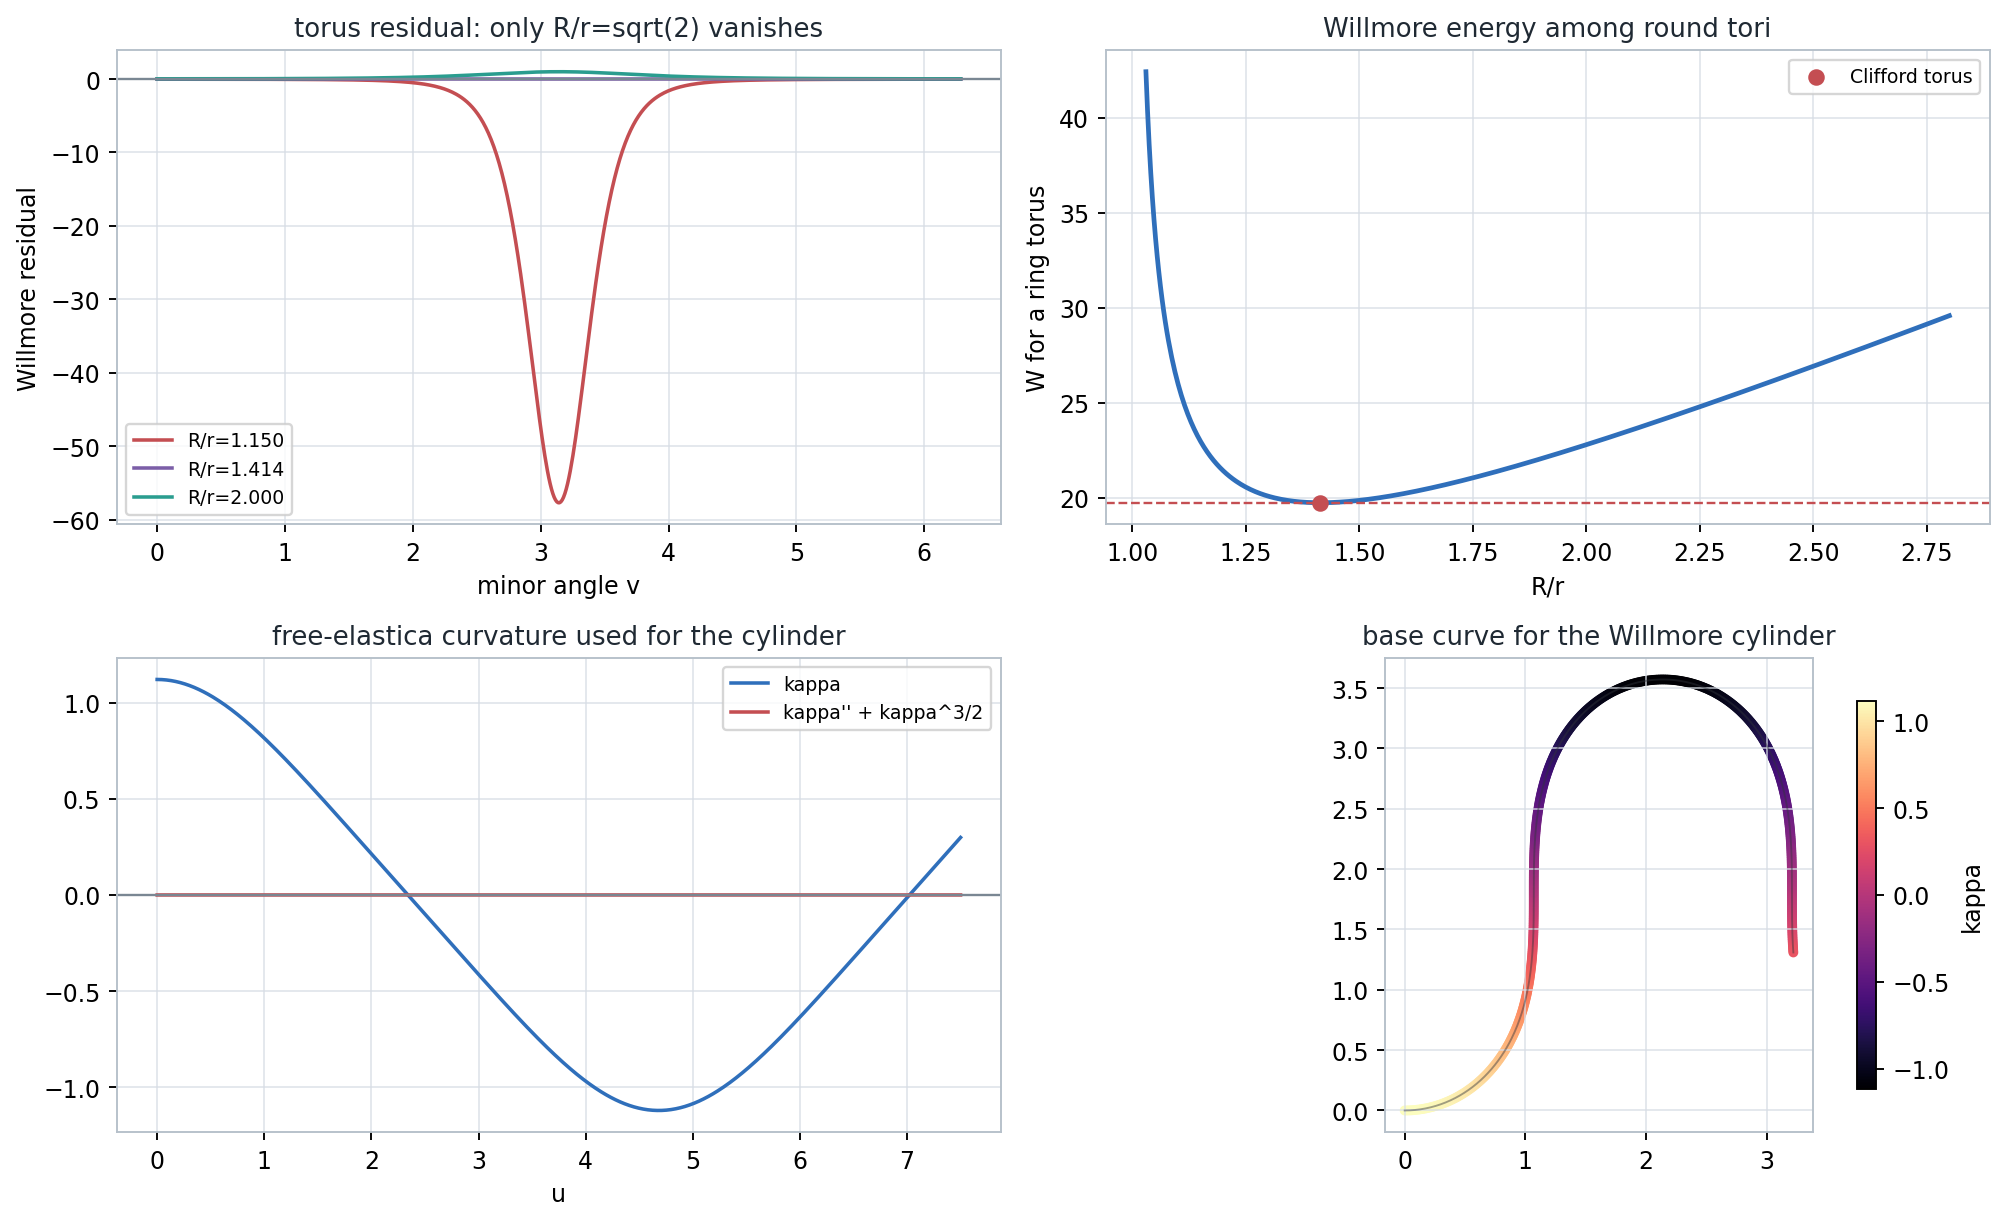

In [6]:
q, v_sym = sp.symbols("q v", positive=True, real=True)
H_torus = (q + 2 * sp.cos(v_sym)) / (2 * (q + sp.cos(v_sym)))
K_torus = sp.cos(v_sym) / (q + sp.cos(v_sym))
sqrt_g = q + sp.cos(v_sym)
laplace_H = (1 / sqrt_g) * sp.diff(sqrt_g * sp.diff(H_torus, v_sym), v_sym)
torus_residual_expr = sp.factor(sp.simplify(laplace_H + 2 * H_torus * (H_torus**2 - K_torus)))
clifford_residual_expr = sp.simplify(torus_residual_expr.subs(q, sp.sqrt(2)))
residual_func = sp.lambdify((q, v_sym), torus_residual_expr, "numpy")

v_grid = np.linspace(0.0, TAU, 600)
ratios = [1.15, math.sqrt(2.0), 2.0]
q_grid = np.linspace(1.03, 2.8, 500)
W_grid = np.array([torus_willmore_exact(ratio, 1.0) for ratio in q_grid])
min_index = int(np.argmin(W_grid))

fig, axes = plt.subplots(2, 2, figsize=(12.0, 7.3))
for ratio, color in zip(ratios, [PALETTE["red"], PALETTE["violet"], PALETTE["teal"]]):
    axes[0, 0].plot(v_grid, residual_func(ratio, v_grid), color=color, label=f"R/r={ratio:.3f}")
axes[0, 0].axhline(0, color=PALETTE["gray"], linewidth=1)
axes[0, 0].set_xlabel("minor angle v")
axes[0, 0].set_ylabel("Willmore residual")
style_axis(axes[0, 0], "torus residual: only R/r=sqrt(2) vanishes")
axes[0, 0].legend(fontsize=8)

axes[0, 1].plot(q_grid, W_grid, color=PALETTE["blue"], linewidth=2)
axes[0, 1].scatter([math.sqrt(2.0)], [2 * math.pi**2], color=PALETTE["red"], zorder=3, label="Clifford torus")
axes[0, 1].axhline(2 * math.pi**2, color=PALETTE["red"], linestyle="--", linewidth=1)
axes[0, 1].set_xlabel("R/r")
axes[0, 1].set_ylabel("W for a ring torus")
style_axis(axes[0, 1], "Willmore energy among round tori")
axes[0, 1].legend(fontsize=8)

axes[1, 0].plot(elastic_cyl["s"], elastic_cyl["kappa"], color=PALETTE["blue"], label="kappa")
axes[1, 0].plot(elastic_cyl["s"], elastic_cyl["residual"], color=PALETTE["red"], label="kappa'' + kappa^3/2")
axes[1, 0].axhline(0, color=PALETTE["gray"], linewidth=1)
axes[1, 0].set_xlabel("u")
style_axis(axes[1, 0], "free-elastica curvature used for the cylinder")
axes[1, 0].legend(fontsize=8)

scatter = axes[1, 1].scatter(elastic_cyl["x"], elastic_cyl["y"], c=elastic_cyl["kappa"], s=10, cmap="magma")
axes[1, 1].plot(elastic_cyl["x"], elastic_cyl["y"], color="#30343b", linewidth=0.8, alpha=0.45)
axes[1, 1].set_aspect("equal", adjustable="box")
style_axis(axes[1, 1], "base curve for the Willmore cylinder")
fig.colorbar(scatter, ax=axes[1, 1], shrink=0.82, label="kappa")
fig.tight_layout()

equation_path = record_artifact(save_matplotlib(fig, TOPIC, "figures", "willmore-equation-and-elastic-cylinder.png", dpi=170))
plt.close(fig)
display_artifact(equation_path, width=940)

clifford_residual_values = np.asarray(residual_func(math.sqrt(2.0), v_grid), dtype=float)
equation_checks = {
    "torus_residual_expression": str(torus_residual_expr),
    "clifford_residual_expression": str(clifford_residual_expr),
    "clifford_residual_max_abs": float(np.max(np.abs(clifford_residual_values))),
    "round_torus_energy_min_ratio_grid": float(q_grid[min_index]),
    "round_torus_energy_min_error_from_sqrt2": abs(float(q_grid[min_index]) - math.sqrt(2.0)),
    "round_torus_min_energy_error_from_2pi2": abs(float(W_grid[min_index]) - 2 * math.pi**2),
    "elastic_cylinder_residual_max_abs": float(np.max(np.abs(elastic_cyl["residual"][4:-4]))),
    "elastic_cylinder_equation": "kappa'' + kappa^3/2 = 0",
}
equation_checks_path = record_artifact(save_json(equation_checks, TOPIC, "checks", "willmore-equation-checks.json"))
display_artifact(equation_checks_path)

CHECKS["clifford_residual_max_abs"] = equation_checks["clifford_residual_max_abs"]
CHECKS["round_torus_energy_min_error_from_sqrt2_grid"] = equation_checks["round_torus_energy_min_error_from_sqrt2"]
CHECKS["elastic_cylinder_residual_max_abs"] = equation_checks["elastic_cylinder_residual_max_abs"]

## 4. Inversion Preserves the Conformal Density

The source derives the effect of inversion `p -> p/<p,p>` on a surface. Lengths scale by `1/<f,f>`, areas by `1/<f,f>^2`, and the principal-curvature gap scales by `-<f,f>`. Therefore

\[
\frac14(\tilde\kappa_1-\tilde\kappa_2)^2\,d\tilde A
=
\frac14(\kappa_1-\kappa_2)^2\,dA
=(H^2-K)dA.
\]

The shape can change dramatically under inversion; the conformal Willmore density does not. The interactive artifact shows a translated torus and its inverted image with a shared density color scale. The translation is only to keep the sampled surface away from the inversion center.

In [7]:
inversion_surface = torus_data(1.25, 0.32, nu=96, nv=72, shift=(2.60, 0.0, 0.0))
points = np.stack([inversion_surface["X"], inversion_surface["Y"], inversion_surface["Z"]], axis=-1)
flat_points = points.reshape(-1, 3)
inverted_flat = invert_points(flat_points)
inverted = inverted_flat.reshape(points.shape)
rho2 = np.sum(points * points, axis=-1)
area_tilde = inversion_surface["dA"] / (rho2 * rho2)
curvature_gap = inversion_surface["k2"] - inversion_surface["k1"]
curvature_gap_tilde = -rho2 * curvature_gap
conformal_original = 0.25 * curvature_gap * curvature_gap * inversion_surface["dA"]
conformal_inverted = 0.25 * curvature_gap_tilde * curvature_gap_tilde * area_tilde
pointwise_error = conformal_inverted - conformal_original
relative_error = np.abs(pointwise_error) / np.maximum(np.abs(conformal_original), 1e-15)

cmin = float(np.quantile(conformal_original, 0.02))
cmax = float(np.quantile(conformal_original, 0.98))
fig = make_subplots(
    rows=1,
    cols=2,
    specs=[[{"type": "surface"}, {"type": "surface"}]],
    subplot_titles=("translated torus", "after inversion in the unit sphere"),
)
fig.add_trace(
    go.Surface(
        x=inversion_surface["X"], y=inversion_surface["Y"], z=inversion_surface["Z"],
        surfacecolor=conformal_original,
        colorscale="Viridis", cmin=cmin, cmax=cmax,
        colorbar={"title": "(H^2-K)dA", "len": 0.72},
        name="original",
    ),
    row=1, col=1,
)
fig.add_trace(
    go.Surface(
        x=inverted[..., 0], y=inverted[..., 1], z=inverted[..., 2],
        surfacecolor=conformal_inverted,
        colorscale="Viridis", cmin=cmin, cmax=cmax,
        showscale=False,
        name="inverted",
    ),
    row=1, col=2,
)
fig.update_layout(
    title="Inversion lab: the shape changes, the conformal density ledger does not",
    height=620,
    margin={"l": 0, "r": 0, "t": 70, "b": 0},
)
for scene_name in ["scene", "scene2"]:
    fig.update_layout(**{scene_name: {"aspectmode": "data", "xaxis": {"visible": False}, "yaxis": {"visible": False}, "zaxis": {"visible": False}}})

inversion_html = record_artifact(save_plotly_html(fig, TOPIC, "interactive", "inversion-conformal-density-lab.html", include_plotlyjs="cdn"))
display_artifact(inversion_html)

inversion_checks = {
    "min_squared_distance_from_inversion_center": float(np.min(rho2)),
    "max_pointwise_density_abs_error": float(np.max(np.abs(pointwise_error))),
    "max_pointwise_density_relative_error": float(np.max(relative_error)),
    "area_scale_formula": "dA_tilde = dA / <f,f>^2",
    "gap_scale_formula": "kappa_gap_tilde = -<f,f> * kappa_gap",
    "conformal_density_formula": "0.25*gap^2*dA is unchanged",
}
inversion_checks_path = record_artifact(save_json(inversion_checks, TOPIC, "checks", "inversion-density-checks.json"))
display_artifact(inversion_checks_path)

CHECKS["inversion_min_squared_distance"] = inversion_checks["min_squared_distance_from_inversion_center"]
CHECKS["inversion_density_max_relative_error"] = inversion_checks["max_pointwise_density_relative_error"]

## 5. Proof and Invariant Scaffold

The chapter's proof logic is compact but easy to blur. The graph below separates three ideas that should not be conflated:

1. Gauss-Bonnet explains why the energy variants have the same local variational content.
2. The first variation identifies the Willmore equation as the interior criticality condition.
3. The inversion calculation preserves the conformal density, which then transports critical points because `W` and `W_hat` have the same compactly supported critical points.

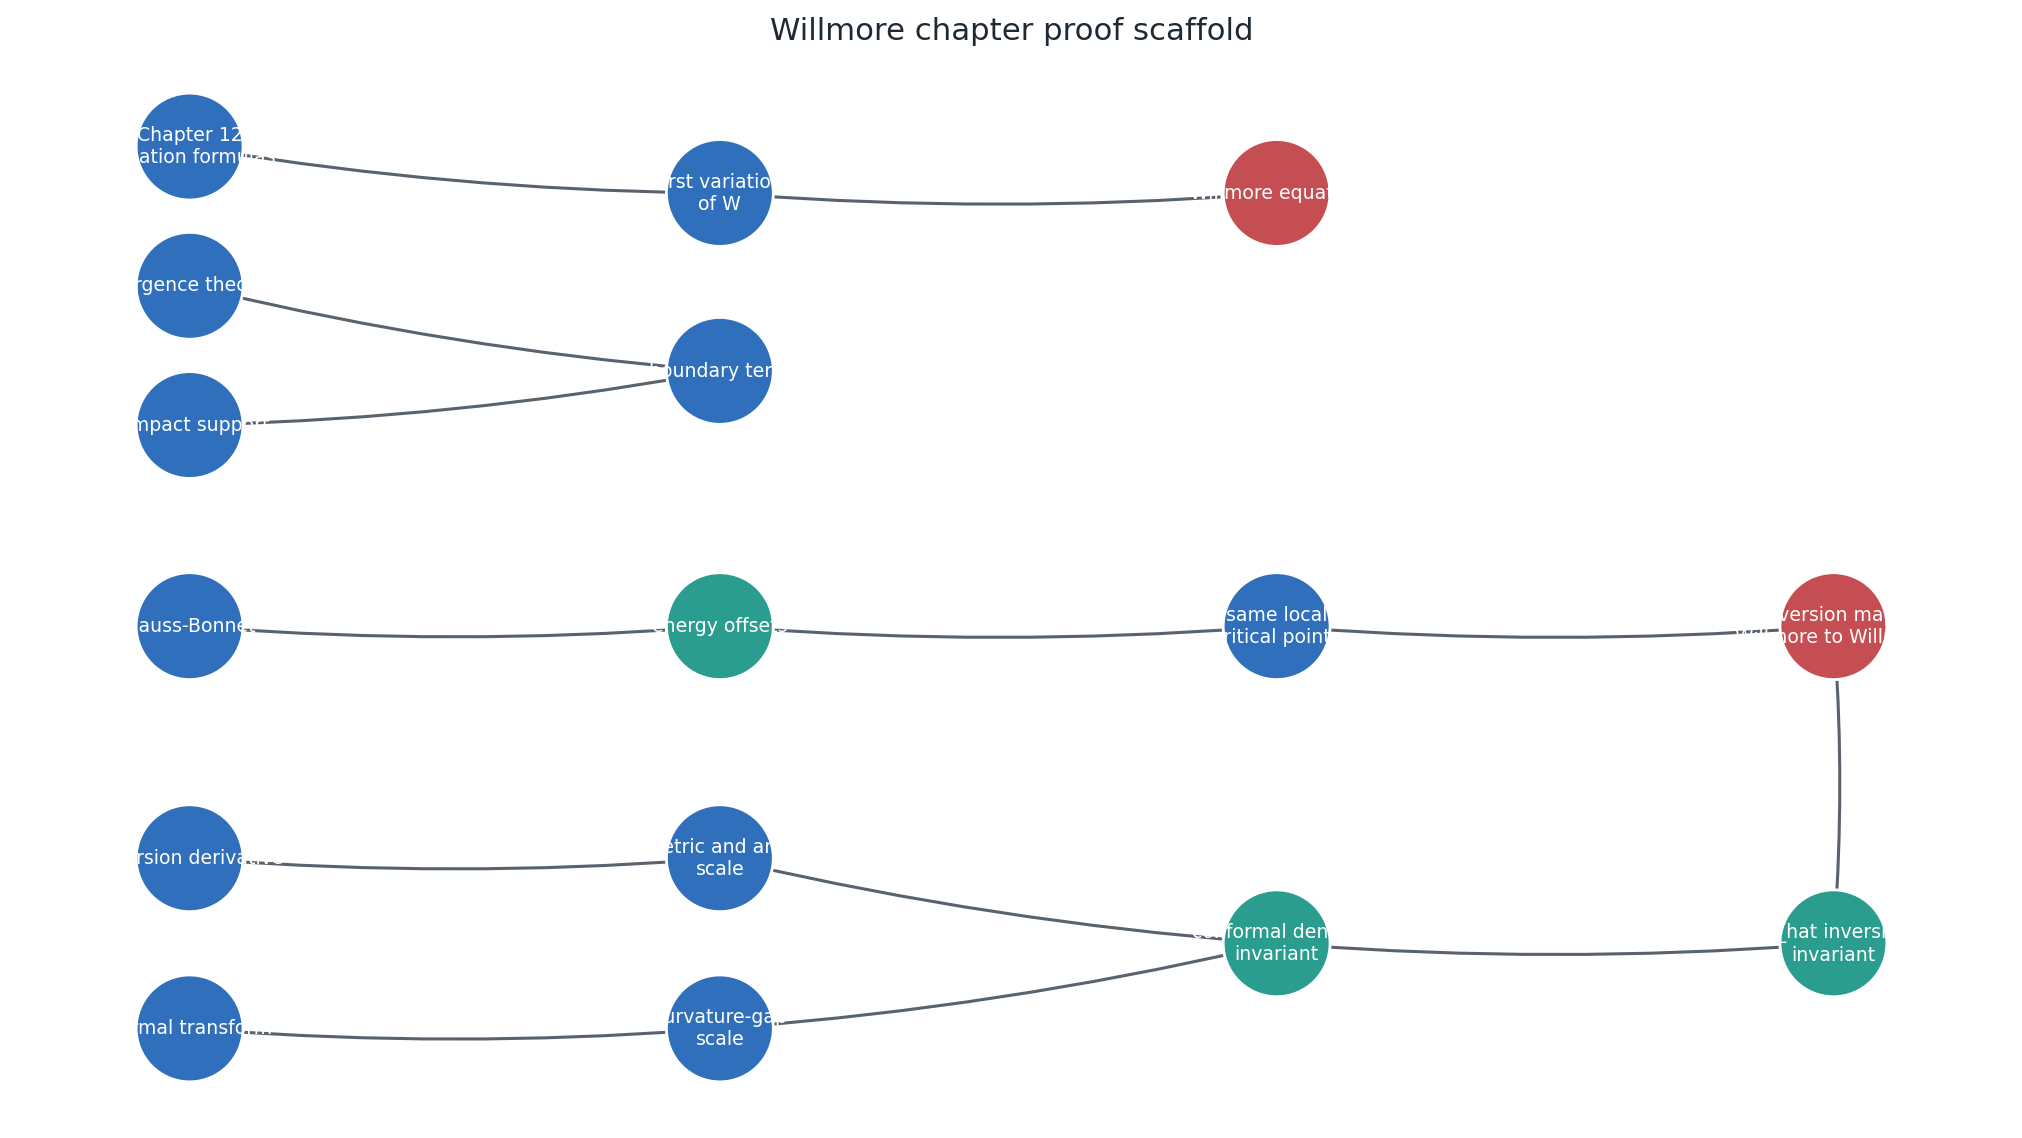

In [8]:
proof_edges = [
    ("Chapter 12\nvariation formulas", "first variation\nof W"),
    ("divergence theorem", "boundary term"),
    ("compact support", "boundary term"),
    ("first variation\nof W", "Willmore equation"),
    ("Gauss-Bonnet", "energy offsets"),
    ("energy offsets", "same local\ncritical points"),
    ("inversion derivative", "metric and area\nscale"),
    ("normal transform", "curvature-gap\nscale"),
    ("metric and area\nscale", "conformal density\ninvariant"),
    ("curvature-gap\nscale", "conformal density\ninvariant"),
    ("conformal density\ninvariant", "W_hat inversion\ninvariant"),
    ("same local\ncritical points", "inversion maps\nWillmore to Willmore"),
    ("W_hat inversion\ninvariant", "inversion maps\nWillmore to Willmore"),
]
G = nx.DiGraph()
G.add_edges_from(proof_edges)
pos = {
    "Chapter 12\nvariation formulas": (0.0, 2.0),
    "divergence theorem": (0.0, 1.1),
    "compact support": (0.0, 0.2),
    "first variation\nof W": (2.0, 1.7),
    "boundary term": (2.0, 0.55),
    "Willmore equation": (4.1, 1.7),
    "Gauss-Bonnet": (0.0, -1.1),
    "energy offsets": (2.0, -1.1),
    "same local\ncritical points": (4.1, -1.1),
    "inversion derivative": (0.0, -2.6),
    "normal transform": (0.0, -3.7),
    "metric and area\nscale": (2.0, -2.6),
    "curvature-gap\nscale": (2.0, -3.7),
    "conformal density\ninvariant": (4.1, -3.15),
    "W_hat inversion\ninvariant": (6.2, -3.15),
    "inversion maps\nWillmore to Willmore": (6.2, -1.1),
}
node_colors = []
for node in G.nodes:
    if node in {"Willmore equation", "inversion maps\nWillmore to Willmore"}:
        node_colors.append(PALETTE["red"])
    elif "invariant" in node or "offset" in node:
        node_colors.append(PALETTE["teal"])
    else:
        node_colors.append(PALETTE["blue"])

fig, ax = plt.subplots(figsize=(12, 6.8))
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=14, width=1.3, edge_color="#59636e", connectionstyle="arc3,rad=0.04")
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=2050, linewidths=1.2, edgecolors="white")
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_color="white")
ax.set_title("Willmore chapter proof scaffold", fontsize=13, color=PALETTE["ink"])
ax.set_axis_off()
fig.tight_layout()
proof_path = record_artifact(save_matplotlib(fig, TOPIC, "figures", "willmore-proof-dependency.png", dpi=170))
plt.close(fig)
display_artifact(proof_path, width=940)

proof_checks = {
    "node_count": G.number_of_nodes(),
    "edge_count": G.number_of_edges(),
    "has_willmore_equation_sink": "Willmore equation" in G.nodes,
    "has_inversion_theorem_sink": "inversion maps\nWillmore to Willmore" in G.nodes,
    "acyclic": nx.is_directed_acyclic_graph(G),
}
proof_checks_path = record_artifact(save_json(proof_checks, TOPIC, "checks", "proof-dependency-checks.json"))
display_artifact(proof_checks_path)
CHECKS["proof_graph_acyclic"] = proof_checks["acyclic"]

## Applied Lab: Move One Parameter, Watch the Residual

The lab is deliberately small. Change the major-to-minor radius ratio `R/r` for a ring torus and ask two questions before reading the output: does the Willmore energy go up or down, and should the Willmore-equation residual vanish? The Clifford value `R/r=sqrt(2)` is the special one among round tori; nearby values may still look visually plausible, but the residual exposes that they are not critical for this family.

In [9]:
lab_ratios = [1.10, 1.25, math.sqrt(2.0), 1.70, 2.30]
lab_rows = []
lab_samples = []
for ratio in lab_ratios:
    residual_samples = np.asarray(residual_func(ratio, v_grid), dtype=float)
    W_value = torus_willmore_exact(ratio, 1.0)
    max_residual = float(np.max(np.abs(residual_samples)))
    lab_rows.append([
        f"{ratio:.6f}",
        f"{W_value:.6f}",
        f"{max_residual:.3e}",
        "yes" if abs(ratio - math.sqrt(2.0)) < 1e-12 else "no",
    ])
    lab_samples.append({"ratio": float(ratio), "W": float(W_value), "max_abs_residual": max_residual})
display(markdown_table(lab_rows, ["R/r", "W", "max |Willmore residual|", "critical round torus?"]))

lab_checks = {
    "samples": lab_samples,
    "instruction": "Change R/r and compare visible torus shape with energy and residual values.",
}
lab_checks_path = record_artifact(save_json(lab_checks, TOPIC, "checks", "round-torus-parameter-lab.json"))
display_artifact(lab_checks_path)

| R/r | W | max |Willmore residual| | critical round torus? |
|---|---|---|---|
| 1.100000 | 26.060063 | 2.172e+02 | no |
| 1.250000 | 20.561676 | 8.749e+00 | no |
| 1.414214 | 19.739209 | 2.209e-15 | yes |
| 1.700000 | 20.747544 | 1.103e+00 | no |
| 2.300000 | 25.207326 | 8.610e-01 | no |

## Final Sanity Checks and Takeaways

The final cell treats the generated pictures as part of the mathematical argument. It checks the identities used in the prose, verifies that every saved artifact exists and is nonempty, and records image statistics so blank figures cannot pass quietly.

Takeaways:

- `W`, `E`, and `W_hat` encode different curvature stories, but Gauss-Bonnet explains their local variational equivalence.
- The Willmore equation is the residual that must vanish after compactly supported normal variations.
- The cylinder example is a bridge back to elastic curves: the surface PDE collapses to the free-elastica ODE for the base curvature.
- Inversion is not visually gentle, but it preserves the conformal density `(H^2-K)dA`, which is the computational heart of the chapter's conformal invariance result.

In [10]:
assert max(CHECKS["sphere_willmore_exact_scale_errors"].values()) < 1e-12
assert CHECKS["sphere_willmore_numeric_error"] < 5e-4
assert CHECKS["clifford_torus_energy_error"] < 5e-3
assert CHECKS["clifford_torus_total_K_abs"] < 5e-12
assert CHECKS["sphere_offset_max_error"] < 1e-12
assert CHECKS["torus_offset_max_error"] < 1e-12
assert str(clifford_residual_expr) == "0"
assert CHECKS["clifford_residual_max_abs"] < 1e-12
assert CHECKS["elastic_cylinder_residual_max_abs"] < 2e-3
assert CHECKS["inversion_min_squared_distance"] > 0.5
assert CHECKS["inversion_density_max_relative_error"] < 1e-12
assert CHECKS["proof_graph_acyclic"] is True

numeric_checks_path = record_artifact(save_json(CHECKS, TOPIC, "checks", "numeric-checks.json"))

artifact_paths = list(dict.fromkeys(ARTIFACTS + [numeric_checks_path]))
final_sanity: dict[str, object] = {
    "source_span": {"printed_pages": "181-191", "pdf_pages": "183-193"},
    "core_checks": CHECKS,
    "artifacts": {},
}
for path in artifact_paths:
    assert path.exists(), path
    assert path.stat().st_size > 0, path
    info: dict[str, object] = {"bytes": int(path.stat().st_size)}
    if path.suffix.lower() == ".png":
        stats = image_stats(path)
        assert stats["pixel_std"] > 1.0, path
        info.update({"width": stats["width"], "height": stats["height"], "pixel_std": stats["pixel_std"], "sha256": stats["sha256"]})
    elif path.suffix.lower() == ".html":
        text = path.read_text(encoding="utf-8")
        assert "Plotly" in text and "inversion" in text.lower(), path
    elif path.suffix.lower() == ".json":
        json.loads(path.read_text(encoding="utf-8"))
    final_sanity["artifacts"][rel(path)] = info

final_sanity_path = save_json(final_sanity, TOPIC, "checks", "final-sanity.json")
display_artifact(numeric_checks_path)
display_artifact(final_sanity_path)